<p><img alt="UdeA logo" height="140px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="10px" vspace="0px"></p>
<div align="center">
  
<h1> <b> Análisis numérico del problema de un péndulo simple desde un sistema no incercial con aceleración periódica.</b> </h1>

</div>

<!-- <br> le permite hacer espacios -->
<br>

<hr size=10 noshade color="green">
<p>


<div align="right">       

<h3><i> <b>Otálvaro Ghisays Juan Pablo, Ortíz Campo Jose David</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
juan.otalvaro1@udea.edu.co
jose.ortizc@udea.edu.co

</i></h3>
</div>


---

# **PLANTEAMIENTO DEL PROBLEMA**

Se quiere estudiar el movimiento de un péndulo simple que va montado en una nave con aceleración $\large \vec{a}$ que puede variar en el tiempo. Para esto se ubicamos un sistema fijado a la nave (no inercial) y un sistema fuera de la nave (inercial), como se puede ver en la siguiente representación gráfica.

<center>
<figure>
  <img src="https://drive.google.com/uc?id=1-yyrBvekCC3QgBR4EWsmkA0vPefhrO84" alt="fig1" width="540" height="530"/>
  <figcaption>Imagen 1. Sistemas de referencia.</figcaption>
</figure>
</center>

La nave tiene aceleración $\large \vec{a}$ respecto al sistema inercial. Si definimos la posición de un punto cualquiera medido desde el sistema no inercial como $\large \vec{r}'$, entonces está claro que la posición de un punto arbitrario medido desde el sistema inercial $\large \vec{r} $puede ser escrito como:

$$\large \vec{r} = \vec{R}+\vec{r}'$$

donde $\vec{R}$ es la posición de la nave desde el sistema no inercial.

Si derivamos dos veces respecto al tiempo tenemos que:

$$\large \ddot{\vec{r}} = \ddot{\vec{R}}+\ddot{\vec{r}}'=  {\vec{a}}+\ddot{\vec{r}}'$$

No hay fuerzas actuando sobre la masa puntual arbitraria, por lo que su aceleración medida desde el sistema inercial es nula, con esto se tiene la siguiente igualdad:

$$\large \ddot{\vec{r}}'=-\vec{a}$$

Es decir, desde el sistema no inercial, la masa puntual está cambiando su velocidad con aceleración $-\large\vec{a}$. Así pues, un péndulo simple que se encuentra en una nave con aceleración $\large\vec{a}$ experimenta una aceleración $\large-\vec{a}$. Eligiendo los ejes coordenados convenientemente, podemos escribir al vector $\large-\vec{a} = -a\hat{\jmath}$.

<center>
<figure>
  <img src="https://drive.google.com/uc?id=1SqIHzJVJ38Bh1IMHzQPAaVncxLSN3x1N" alt="fig1" width="710" height="530"/>
  <figcaption>Imagen 2. Esquema del problema.</figcaption>
</figure>
</center>



Así, el problema a tratar es análogo al problema de un péndulo simple bajo la acción de un campo gravitacional $\vec{g}=-g\vec{\jmath}$. El potencial entonces será de la forma $U=may$. Podemos escribir el lagrangiano del sistema como:

$$\large L = \frac{1}{2}ml^2\dot\phi+mal\cos\phi$$

La ecuación de movimiento será entonces:

$$\large \ddot{\phi}+\frac{a}{l}\sin\phi=0$$

Tomando terminos de hasta orden 5 tenemos:

$$\large \ddot{\phi}+\frac{a}{l}\phi=\frac{a}{6l}\phi^3-\frac{a}{120l}\phi^5$$

Ahora, si la aceleración de la nave es una función del tiempo $a = a(t)$, por lo que podemos escribir la ecuación de movimiento como:

\

$$\large \ddot{\phi}+\omega_0^2(t)\phi=\alpha(t)\phi^3+\beta(t)\phi^5$$

donde

* $\omega_0^2(t) = a(t)/l$
* $\alpha(t) = \omega_0^2(t)/6 =a(t)/6l$
* $\beta(t) = -\omega_0^2(t)/120=-a(t)/120l$

# **ACELERACIÓN CON FORMA DE ONDA CUADRADA**

Si la nave enciende sus motores, mantiene una aceleración constante, luego apaga sus motores y repite el procedimiento, entonces la función $a(t)$ es una onda cuadrada.

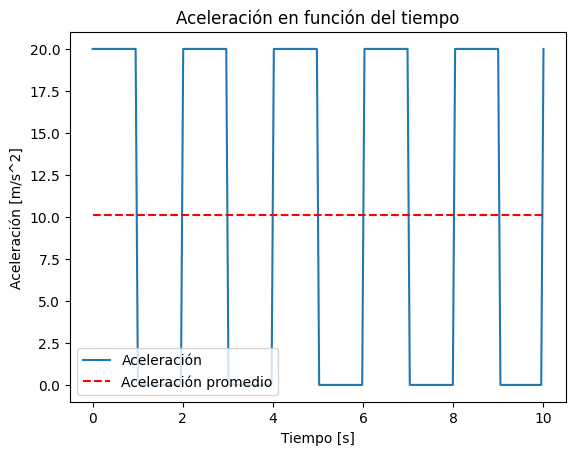

In [ ]:
#@title **Onda cuadrada**
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

def w1(t, frecuencia=.5):
    periodo = 1.0 / frecuencia
    wave = np.where(np.mod(t, periodo) < periodo / 2, 1.0, -1.0)
    return wave+1
#-------------------------------------------------------------------------
t=np.linspace(0,10,200)
fig,ax = plt.subplots()
ax.plot(t,10*w1(t),label='Aceleración')
ax.plot(t,np.mean(10*w1(t))*np.ones(len(t)),'--r',label='Aceleración promedio')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Aceleración [m/s^2]')
ax.set_title('Aceleración en función del tiempo')
ax.legend()
print('')

Supongamos que el péndulo en nuestra nave tiene una longitud de $l = 1 \text{ m}$ y que la aceleración máxima de nuestra nave es $a_{\text{max}} = 2g =  19.6 \text{ m/s}^2$. De esta forma, nuestra frecuencia natural oscila entre los valores $0 \text{ s}^{-1}<\omega^2(t)<19.6\text{ s}^{-1}$ y tiene un valor promedio de $\omega_0^2 = 9.8 \text{ s}^{-1}$. Veamos cómo se comporta el oscilador cuando la frecuencia con que varía la aceleración es cercana a la frecuencia $\omega_0^2$.

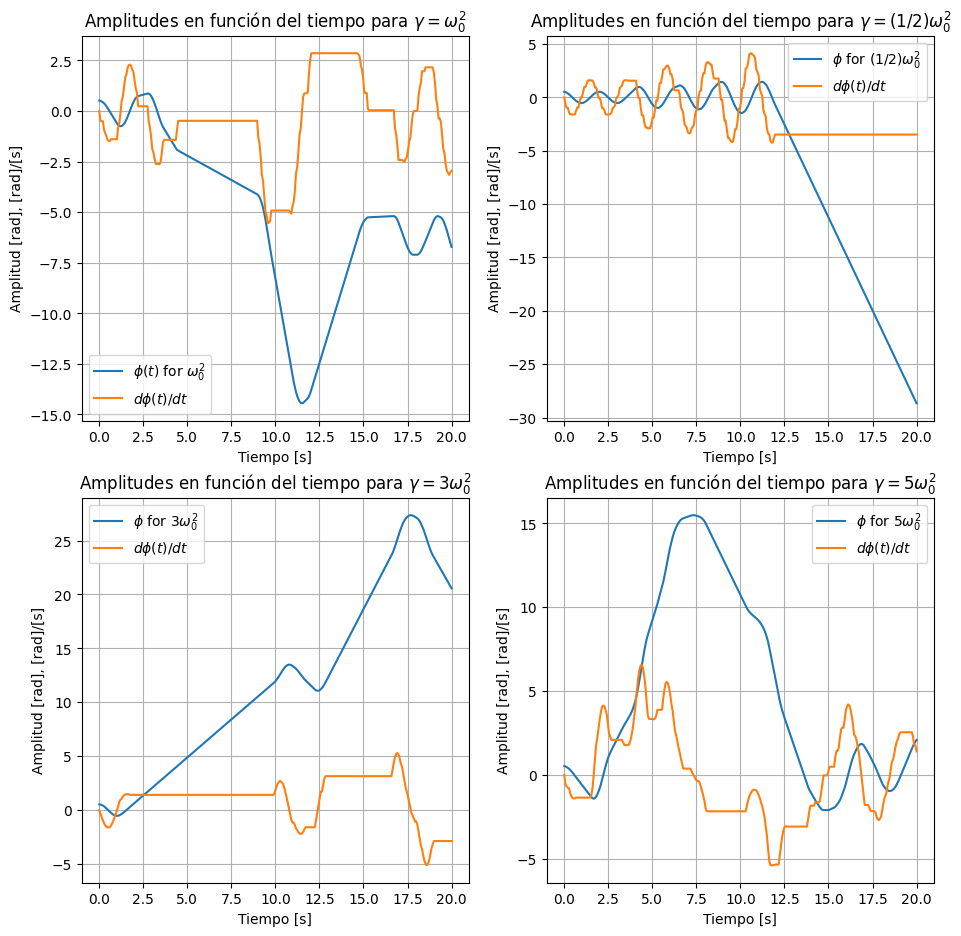

In [ ]:
#@title **Amplitudes en función del tiempo para $\gamma = \omega_0^2, \frac{1}{2}\omega_0^2,3\omega_0^2,5\omega_0^2$**

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
yo = [np.pi/6,0]
t = np.linspace(0,20,300)

def pend0(y,t):
  theta,v = y
  dydt = [v,-9.8*w1(t,9.8)*np.sin(theta)]
  return dydt

def pend1(y,t):
  theta,v = y
  dydt = [v,-9.8*w1(t,9.8/2)*np.sin(theta)]
  return dydt

def pend2(y,t):
  theta,v = y
  dydt = [v,-9.8*w1(t,3*9.8)*np.sin(theta)]
  return dydt

def pend3(y,t):
  theta,v = y
  dydt = [v,-9.8*w1(t,5*9.8)*np.sin(theta)]
  return dydt

sol0 = odeint(pend0,yo,t)
sol0 = np.transpose(sol0)

sol1 = odeint(pend1,yo,t)
sol1 = np.transpose(sol1)

sol2 = odeint(pend2,yo,t)
sol2 = np.transpose(sol2)

sol3 = odeint(pend3,yo,t)
sol3 = np.transpose(sol3)

fig,ax = plt.subplots(2,2,figsize=(11,11))


ax[0][0].plot(t,sol0[0],"-",label="$\phi(t)$ for $\omega_0^2$")
ax[0][0].plot(t,sol0[1],"-",label= "$d{\phi}(t)/dt$")

ax[0][1].plot(t,sol1[0],"-",label="$\phi$ for $(1/2)\omega_0^2$")
ax[0][1].plot(t,sol1[1],"-",label= "$d{\phi}(t)/dt$")

ax[1][0].plot(t,sol2[0],"-",label="$\phi$ for $3\omega_0^2$")
ax[1][0].plot(t,sol2[1],"-",label= "$d{\phi}(t)/dt$")

ax[1][1].plot(t,sol3[0],"-",label="$\phi$ for $5\omega_0^2$")
ax[1][1].plot(t,sol3[1],"-",label= "$d{\phi}(t)/dt$")

for i in range(2):
  for j in range(2):
    ax[i][j].grid()
    ax[i][j].legend()
    ax[i][j].set_xlabel("Tiempo [s]")
    ax[i][j].set_ylabel("Amplitud [rad], [rad]/[s]")

ax[0][0].set_title("Amplitudes en función del tiempo para $\gamma = \omega_0^2$")
ax[0][1].set_title("Amplitudes en función del tiempo para $\gamma = (1/2)\omega_0^2$")
ax[1][0].set_title("Amplitudes en función del tiempo para $\gamma = 3\omega_0^2$")
ax[1][1].set_title("Amplitudes en función del tiempo para $\gamma = 5\omega_0^2$")
print('')

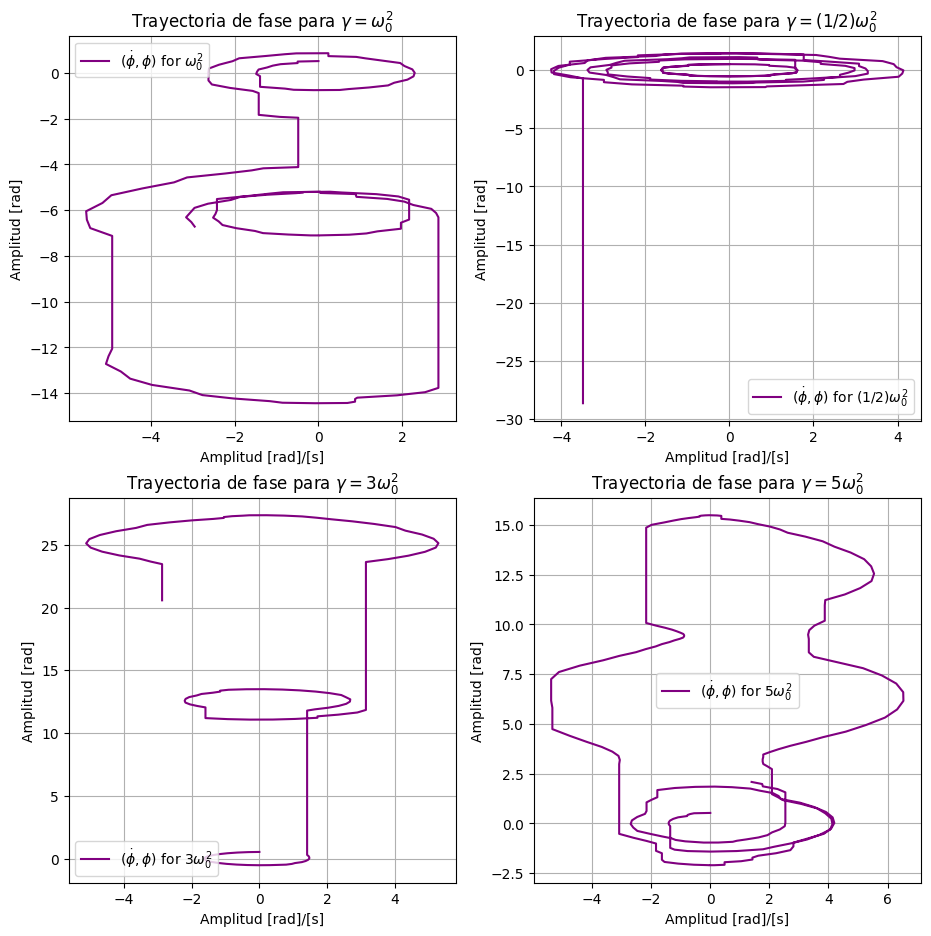

In [ ]:
#@title **Trayectorias de fase**
fig,ax = plt.subplots(2,2,figsize=(11,11))


ax[0][0].plot(sol0[1],sol0[0],"-",color='purple',label="$(\dot{\phi},\phi)$ for $\omega_0^2$")
ax[0][1].plot(sol1[1],sol1[0],"-",color='purple',label="$(\dot{\phi},\phi)$ for $(1/2)\omega_0^2$")
ax[1][0].plot(sol2[1],sol2[0],"-",color='purple',label="$(\dot{\phi},\phi)$ for $3\omega_0^2$")
ax[1][1].plot(sol3[1],sol3[0],"-",color='purple',label="$(\dot{\phi},\phi)$ for $5\omega_0^2$")

for i in range(2):
  for j in range(2):
    ax[i][j].grid()
    ax[i][j].legend()
    ax[i][j].set_xlabel("Amplitud [rad]/[s]")
    ax[i][j].set_ylabel("Amplitud [rad]")

ax[0][0].set_title("Trayectoria de fase para $\gamma = \omega_0^2$")
ax[0][1].set_title("Trayectoria de fase para $\gamma = (1/2)\omega_0^2$")
ax[1][0].set_title("Trayectoria de fase para $\gamma = 3\omega_0^2$")
ax[1][1].set_title("Trayectoria de fase para $\gamma = 5\omega_0^2$")
print('')

Como se puede ver en los primeros 4 gráficos, existe resonancia para todas las frecuencias muestreadas. Esta resonancia se muestra también en las trayectorias de fase: En ninguno de los gráficos se ve la formación de un atractor, es decir, un estado en el que el sistema se estabilice.

Visualicemos el movimiento del péndulo cuando la frecuencia es $0.5$ veces la frecuencia promedio desde los dos sistemas.

In [ ]:
#@title **Resonancia paramétrica (sistema no inercial)**
import matplotlib.animation as animation
import math
def anim(l,t,theta):
  """"""
  #-------------------------------------------------------------------------------------------------------------------------------------
  try: #Intente
    #-------------------------------------------------------
    fig = plt.figure(figsize=(6,6)) #Creamos la figura
    ax = fig.gca() #Llamamos los ejes
    x = np.sin(theta)
    y = -np.cos(theta)
    ax.set_title("Péndulo en una nave con $\gamma = 3\omega_0^2$")
    #---------------------------------------------------------------------------------------------
    def actualizar(i): #Definimos la función de update
      #En cada iteración...
      ax.clear() #Limpia la figura
      #Llama dos vectores.
      #El primero va desde 0 hasta x[i]
      #El segundo va desde 0 hasta y[i]
      #Los "suma" y así tenemos el vector que va desde 0 hasta la posición del péndulo
      ax.plot([0,x[i]],[0,y[i]],"-o",markersize=20)
      ax.set_xlim(-1.25*l, 1.25*l) #Los límites en los ejes están calibrados para l=1, así cuando l=0.1, el límite decrece
      ax.set_ylim(-1.25*l, 1.25*l) #Los límites en y están invertidos

      ax.annotate(" x = %.3f m \n y = %.4f m"%(x[i],y[i]), xy=(x[i],y[i]), xytext=[x[i]+l*0.05, y[i]]) #Con esto anotamos los valores de x,y
      ax.annotate("theta = %.3f grados"%(theta[i]*180/math.pi), xy=(x[i],y[i]), xytext=[l*0.1, 0])#Aquí anotamos el valor del ángulo en sexagesimal
      ax.annotate("%.3f segundos"%(t[i]), xy=(x[i],y[i]), xytext=[l*-0.6, l*-0.1]) #Aquí anotamos el paso del tiempo

      ax.grid() #Creamos un grid
    #---------------------------------------------------------------------------------------------

    #Como son 20 segundos --> 20000 ms.
    #Como son 300 frames --> 20000 ms/300 ms/frames
    ani = animation.FuncAnimation(fig,actualizar,range(len(x)),repeat = True, interval = 20000/300)
    #cerramos la figura
    plt.close(fig)
    #------------------------------------------
    return ani #retornamos la animación
  #----------------------------------------------------------------------------------------------------------------------------------------------------------
  except Exception as error: #Si sucede un error
    print(error) #Imprima el error

noinercial = anim(1,t,sol1[0])
from IPython.display import HTML
HTML(noinercial.to_html5_video())

In [ ]:
#@title **Desplazamiento del sistema no inercial respecto al inercial**
#Para hacer que el sistema sea inercial, debemos hacer que el sistema anterior se mueva con la velocidad de la nave
#Podemos calcular la velocidad de la nave integrando la función de aceleración

from scipy.integrate import quad
from scipy.special import erf
t =  np.linspace(0,20,300)
def w1a(t, frecuencia=0.5*9.8):
    periodo = 1.0 / frecuencia
    wave = np.where(np.mod(t, periodo) < periodo / 2, 1.0, -1.0)
    return wave+1

def v(T):
  jnu,error = quad(w1a,0,T)
  return jnu
#Calculemos la velocidad en cada tiempo muestreado
vy=[]
for i in t:
  vy.append(v(i))

#La animación dura 20 segundos y tiene 300 frames
dt = 20/300

#Calculemos el desplazamiento por frame
yx = []
h = 0
for i in range(len(vy)):
  h += 9.8*vy[i]*dt
  yx.append(h)

print('')

<ipython-input-6-8526d1515e57>:14: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  jnu,error = quad(w1a,0,T)
<ipython-input-6-8526d1515e57>:14: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  jnu,error = quad(w1a,0,T)


Nota: El codigo anterior fué un intento fallido, no afecta los demás anteriores.

In [ ]:
#@title **Resonancia paramétrica (sistema inercial)**

def anima(l,t,theta):
  """ """
  #-------------------------------------------------------------------------------------------------------------------------------------
  try: #Intente
    #-------------------------------------------------------
    fig = plt.figure(figsize=(6,6)) #Creamos la figura
    ax = fig.gca() #Llamamos los ejes
    x = np.sin(theta)
    y = -np.cos(theta)
    #---------------------------------------------------------------------------------------------
    def actualizar(i): #Definimos la función de update
      #En cada iteración...
      ax.clear() #Limpia la figura
      #Llama dos vectores.
      #El primero va desde 0 hasta x[i]
      #El segundo va desde 0 hasta y[i]
      #Los "suma" y así tenemos el vector que va desde 0 hasta la posición del péndulo
      #Le sumamos el desplazamiento en y
      ax.plot([0,x[i]],[0+yx[i],y[i]+yx[i]],"-o",markersize=20)
      ax.arrow(0, yx[i], 0,0.5*w1a(t[i]), head_width=0.1, head_length=0.1,color='black')

      ax.set_xlim(-1.25*l, 1.25*l) #Los límites en los ejes están calibrados para l=1, así cuando l=0.1, el límite decrece
      ax.set_ylim(-1.25*l+yx[i], yx[i]+1.25*l) #Los límites en y están invertidos

      ax.annotate(" x = %.3f m \n y = %.4f m"%(x[i],y[i]), xy=(x[i],y[i]+yx[i]), xytext=[x[i]+l*0.05, yx[i]+y[i]]) #Con esto anotamos los valores de x,y
      ax.annotate("theta = %.3f grados"%(theta[i]*180/math.pi), xy=(x[i],y[i]+yx[i]), xytext=[l*0.1, 0+yx[i]])#Aquí anotamos el valor del ángulo en sexagesimal
      ax.annotate("%.3f segundos"%(t[i]), xy=(x[i],y[i]+yx[i]), xytext=[l*-0.6, yx[i]+l*-0.1]) #Aquí anotamos el paso del tiempo
      ax.annotate("%.3f Aceleración"%(9.8*w1a(t[i])), xy=(x[i],y[i]+yx[i]+0.5), xytext=[l*-0.6, yx[i]+l*-0.1+0.5]) #Aquí anotamos el paso del tiempo

      ax.grid() #Creamos un grid
    #---------------------------------------------------------------------------------------------

    #Como son 20 (10) segundos --> 20000 (10000) ms.
    #Como son 200 frames --> 20000 ms/200 (10000)/(400)frames ---> 100ms/frames
    ani = animation.FuncAnimation(fig,actualizar,range(len(x)),repeat = True, interval = 20000/300)
    #cerramos la figura
    plt.close(fig)
    #------------------------------------------
    return ani #retornamos la animación
  #----------------------------------------------------------------------------------------------------------------------------------------------------------
  except Exception as error: #Si sucede un error
    print(error) #Imprima el error

inercial = anima(1,t,sol1[0])
from IPython.display import HTML
HTML(inercial.to_html5_video())

# **ACELERACIÓN CON FORMA DE DIENTE DE SIERRA**

Si la nave enciende sus motores, aumenta su aceleración linealmente, luego disminuye su aceleración linealmente y repite el procedimiento, entonces la función $a(t)$ tiene la  forma de la función diente de sierra.

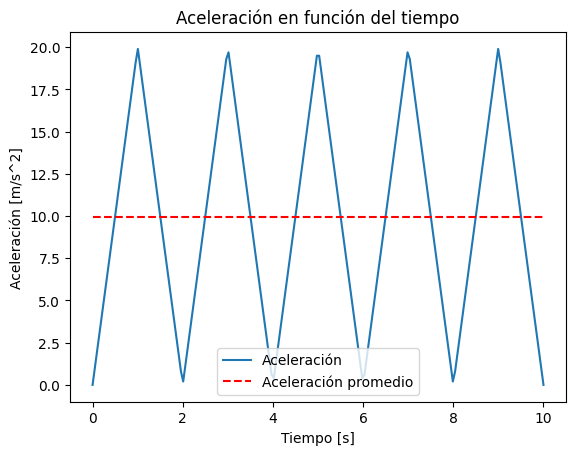

In [ ]:
#@title **Diente de sierra**
from scipy import signal

def w2(t, f=.5):
    return signal.sawtooth(2*np.pi*f*t,width=.5)+1

#-------------------------------------------------------------------------
t=np.linspace(0,10,200)
fig,ax = plt.subplots()
ax.plot(t,10*w2(t),label='Aceleración')
ax.plot(t,np.mean(10*w2(t))*np.ones(len(t)),'--r',label='Aceleración promedio')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Aceleración [m/s^2]')
ax.set_title('Aceleración en función del tiempo')
ax.legend()
print('')



Supongamos que el péndulo en nuestra nave tiene una longitud de $l = 1 \text{ m}$ y que la aceleración máxima de nuestra nave es $a_{\text{max}} = 2g =  19.6 \text{ m/s}^2$. De esta forma, nuestra frecuencia natural oscila entre los valores $0 \text{ s}^{-1}<\omega^2(t)<19.6\text{ s}^{-1}$ y tiene un valor promedio de $\omega_0^2 = 9.8 \text{ s}^{-1}$. Veamos cómo se comporta el oscilador cuando la frecuencia con que varía la aceleración es cercana a la frecuencia $\omega_0^2$.

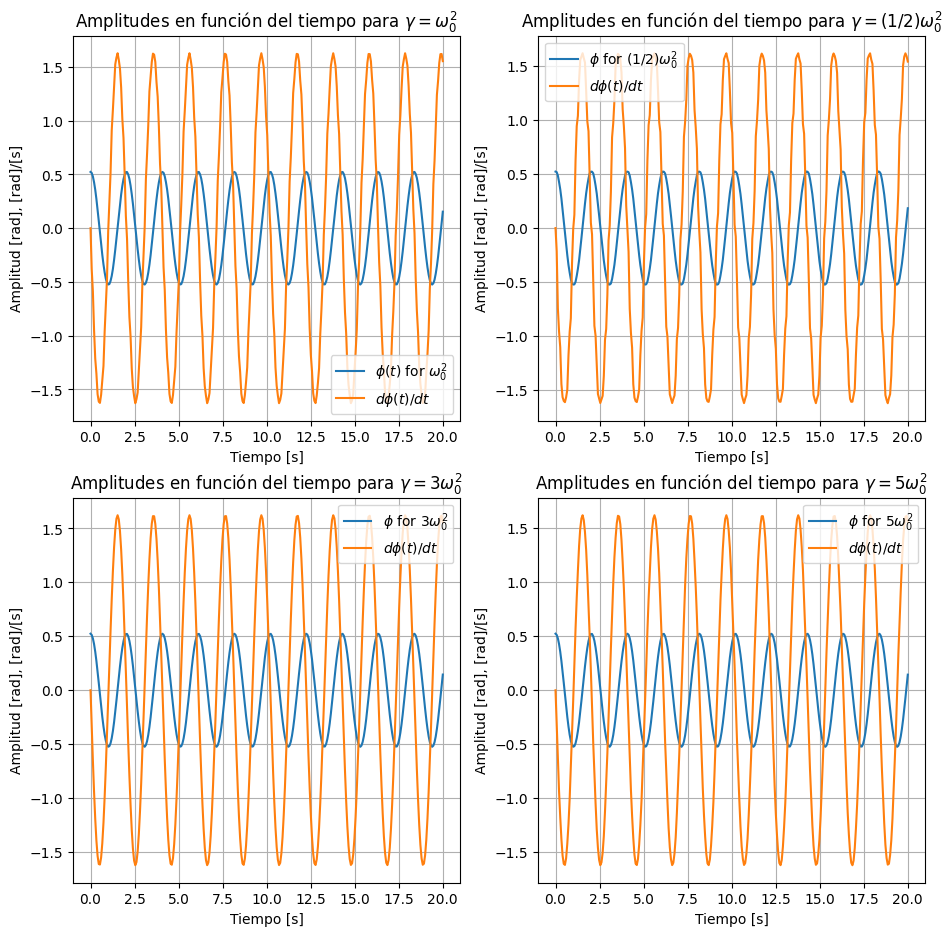

In [ ]:
#@title **Amplitudes en función del tiempo para $\gamma = \omega_0^2, \frac{1}{2}\omega_0^2,3\omega_0^2,5\omega_0^2$**

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
yo = [np.pi/6,0]
t = np.linspace(0,20,300)

def pend0b(y,t):
  theta,v = y
  dydt = [v,-9.8*w2(t,9.8)*np.sin(theta)]
  return dydt

def pend1b(y,t):
  theta,v = y
  dydt = [v,-9.8*w2(t,9.8/2)*np.sin(theta)]
  return dydt

def pend2b(y,t):
  theta,v = y
  dydt = [v,-9.8*w2(t,3*9.8)*np.sin(theta)]
  return dydt

def pend3b(y,t):
  theta,v = y
  dydt = [v,-9.8*w2(t,5*9.8)*np.sin(theta)]
  return dydt

sol0b = odeint(pend0b,yo,t)
sol0b = np.transpose(sol0b)

sol1b = odeint(pend1b,yo,t)
sol1b = np.transpose(sol1b)

sol2b = odeint(pend2b,yo,t)
sol2b = np.transpose(sol2b)

sol3b = odeint(pend3b,yo,t)
sol3b = np.transpose(sol3b)

fig,ax = plt.subplots(2,2,figsize=(11,11))


ax[0][0].plot(t,sol0b[0],"-",label="$\phi(t)$ for $\omega_0^2$")
ax[0][0].plot(t,sol0b[1],"-",label= "$d{\phi}(t)/dt$")

ax[0][1].plot(t,sol1b[0],"-",label="$\phi$ for $(1/2)\omega_0^2$")
ax[0][1].plot(t,sol1b[1],"-",label= "$d{\phi}(t)/dt$")

ax[1][0].plot(t,sol2b[0],"-",label="$\phi$ for $3\omega_0^2$")
ax[1][0].plot(t,sol2b[1],"-",label= "$d{\phi}(t)/dt$")

ax[1][1].plot(t,sol3b[0],"-",label="$\phi$ for $5\omega_0^2$")
ax[1][1].plot(t,sol3b[1],"-",label= "$d{\phi}(t)/dt$")

for i in range(2):
  for j in range(2):
    ax[i][j].grid()
    ax[i][j].legend()
    ax[i][j].set_xlabel("Tiempo [s]")
    ax[i][j].set_ylabel("Amplitud [rad], [rad]/[s]")

ax[0][0].set_title("Amplitudes en función del tiempo para $\gamma = \omega_0^2$")
ax[0][1].set_title("Amplitudes en función del tiempo para $\gamma = (1/2)\omega_0^2$")
ax[1][0].set_title("Amplitudes en función del tiempo para $\gamma = 3\omega_0^2$")
ax[1][1].set_title("Amplitudes en función del tiempo para $\gamma = 5\omega_0^2$")
print('')

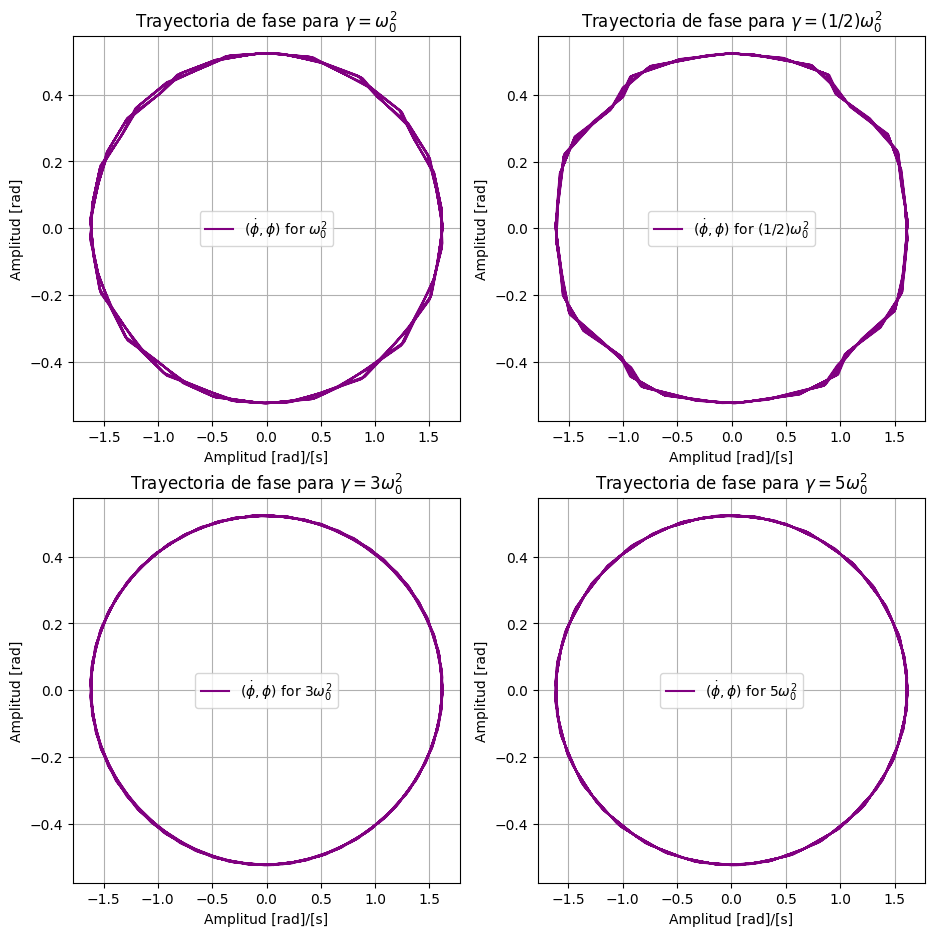

In [ ]:
#@title **Trayectorias de fase**
fig,ax = plt.subplots(2,2,figsize=(11,11))


ax[0][0].plot(sol0b[1],sol0b[0],"-",color='purple',label="$(\dot{\phi},\phi)$ for $\omega_0^2$")
ax[0][1].plot(sol1b[1],sol1b[0],"-",color='purple',label="$(\dot{\phi},\phi)$ for $(1/2)\omega_0^2$")
ax[1][0].plot(sol2b[1],sol2b[0],"-",color='purple',label="$(\dot{\phi},\phi)$ for $3\omega_0^2$")
ax[1][1].plot(sol3b[1],sol3b[0],"-",color='purple',label="$(\dot{\phi},\phi)$ for $5\omega_0^2$")

for i in range(2):
  for j in range(2):
    ax[i][j].grid()
    ax[i][j].legend()
    ax[i][j].set_xlabel("Amplitud [rad]/[s]")
    ax[i][j].set_ylabel("Amplitud [rad]")

ax[0][0].set_title("Trayectoria de fase para $\gamma = \omega_0^2$")
ax[0][1].set_title("Trayectoria de fase para $\gamma = (1/2)\omega_0^2$")
ax[1][0].set_title("Trayectoria de fase para $\gamma = 3\omega_0^2$")
ax[1][1].set_title("Trayectoria de fase para $\gamma = 5\omega_0^2$")
print('')

Como se puede ver en los primeros 4 gráficos, el sistema alcanza un estado de equilibrio estable para las 4 frecuencias usadas. Este  estado también se puede visualizar en las trayectorrias de fase, en los 4 gráficos se ve la formación de un atractor.

Tratemos de encontrar un rango de frecuencias en el que exista resonancia.

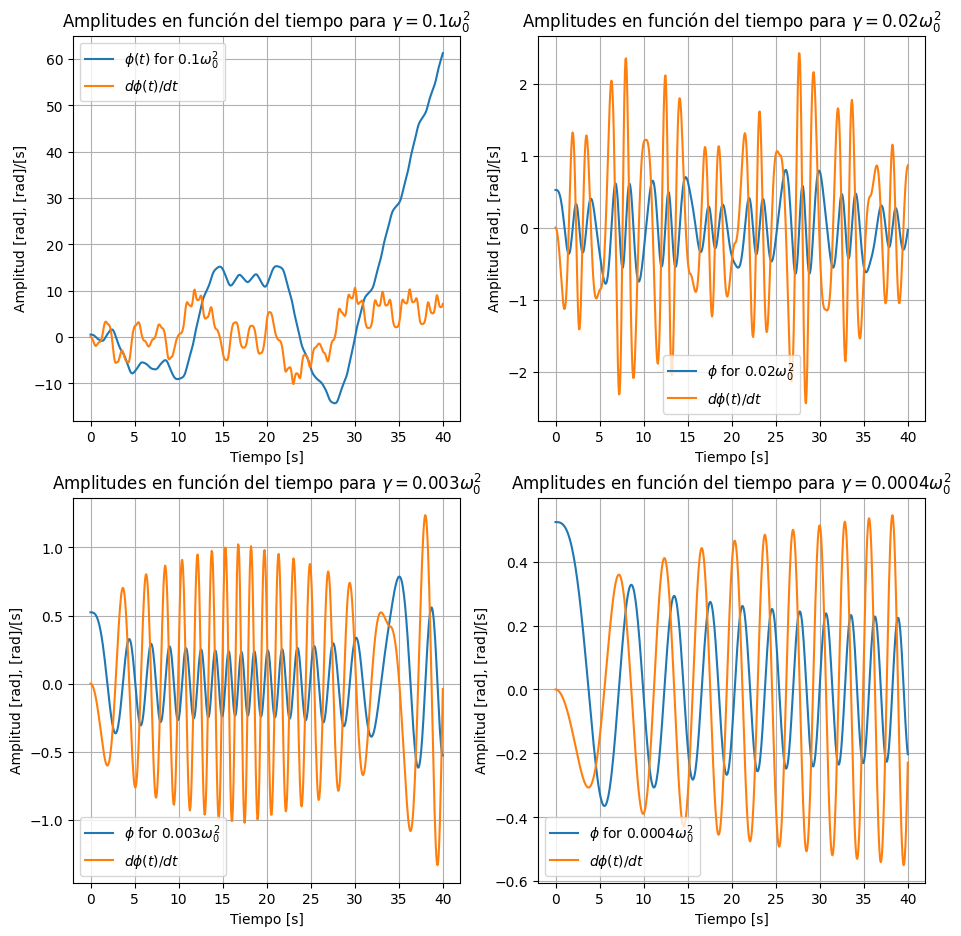

In [ ]:
#@title **Amplitudes en función del tiempo para $\gamma = 0.1\omega_0^2, 0.02\omega_0^2,0.003\omega_0^2,0.0004\omega_0^2$**

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
yo = [np.pi/6,0]
t = np.linspace(0,40,600)

def pend0c(y,t):
  theta,v = y
  dydt = [v,-9.8*w2(t,0.1*9.8)*np.sin(theta)]
  return dydt

def pend1c(y,t):
  theta,v = y
  dydt = [v,-9.8*w2(t,0.02*9.8)*np.sin(theta)]
  return dydt

def pend2c(y,t):
  theta,v = y
  dydt = [v,-9.8*w2(t,0.003*9.8)*np.sin(theta)]
  return dydt

def pend3c(y,t):
  theta,v = y
  dydt = [v,-9.8*w2(t,0.0004*9.8)*np.sin(theta)]
  return dydt

sol0c = odeint(pend0c,yo,t)
sol0c = np.transpose(sol0c)

sol1c = odeint(pend1c,yo,t)
sol1c = np.transpose(sol1c)

sol2c = odeint(pend2c,yo,t)
sol2c = np.transpose(sol2c)

sol3c = odeint(pend3c,yo,t)
sol3c = np.transpose(sol3c)

fig,ax = plt.subplots(2,2,figsize=(11,11))


ax[0][0].plot(t,sol0c[0],"-",label="$\phi(t)$ for $0.1\omega_0^2$")
ax[0][0].plot(t,sol0c[1],"-",label= "$d{\phi}(t)/dt$")
ax[0][1].plot(t,sol1c[0],"-",label="$\phi$ for $0.02\omega_0^2$")
ax[0][1].plot(t,sol1c[1],"-",label= "$d{\phi}(t)/dt$")
ax[1][0].plot(t,sol2c[0],"-",label="$\phi$ for $0.003\omega_0^2$")
ax[1][0].plot(t,sol2c[1],"-",label= "$d{\phi}(t)/dt$")
ax[1][1].plot(t,sol3c[0],"-",label="$\phi$ for $0.0004\omega_0^2$")
ax[1][1].plot(t,sol3c[1],"-",label= "$d{\phi}(t)/dt$")

for i in range(2):
  for j in range(2):
    ax[i][j].grid()
    ax[i][j].legend()
    ax[i][j].set_xlabel("Tiempo [s]")
    ax[i][j].set_ylabel("Amplitud [rad], [rad]/[s]")

ax[0][0].set_title("Amplitudes en función del tiempo para $\gamma = 0.1\omega_0^2$")
ax[0][1].set_title("Amplitudes en función del tiempo para $\gamma = 0.02\omega_0^2$")
ax[1][0].set_title("Amplitudes en función del tiempo para $\gamma = 0.003\omega_0^2$")
ax[1][1].set_title("Amplitudes en función del tiempo para $\gamma = 0.0004\omega_0^2$")
print('')

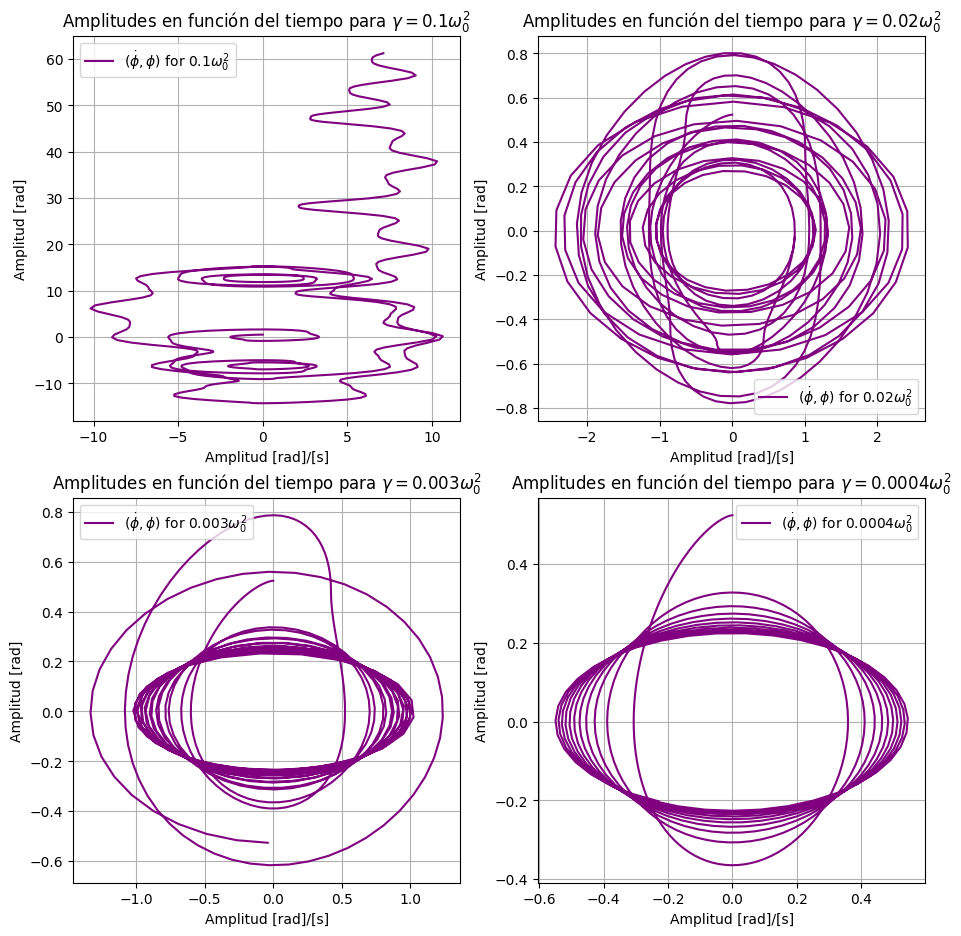

In [ ]:
#@title **Trayectorias de fase**
fig,ax = plt.subplots(2,2,figsize=(11,11))


ax[0][0].plot(sol0c[1],sol0c[0],"-",color='purple',label="$(\dot{\phi},\phi)$ for $0.1\omega_0^2$")
ax[0][1].plot(sol1c[1],sol1c[0],"-",color='purple',label="$(\dot{\phi},\phi)$ for $0.02\omega_0^2$")
ax[1][0].plot(sol2c[1],sol2c[0],"-",color='purple',label="$(\dot{\phi},\phi)$ for $0.003\omega_0^2$")
ax[1][1].plot(sol3c[1],sol3c[0],"-",color='purple',label="$(\dot{\phi},\phi)$ for $0.0004\omega_0^2$")

for i in range(2):
  for j in range(2):
    ax[i][j].grid()
    ax[i][j].legend()
    ax[i][j].set_xlabel("Amplitud [rad]/[s]")
    ax[i][j].set_ylabel("Amplitud [rad]")

ax[0][0].set_title("Amplitudes en función del tiempo para $\gamma = 0.1\omega_0^2$")
ax[0][1].set_title("Amplitudes en función del tiempo para $\gamma = 0.02\omega_0^2$")
ax[1][0].set_title("Amplitudes en función del tiempo para $\gamma = 0.003\omega_0^2$")
ax[1][1].set_title("Amplitudes en función del tiempo para $\gamma = 0.0004\omega_0^2$")
print('')

Hay resonancia para $0.1\omega_0^2$ como se puede ver en el gráfico de amplitudes y en el de trayectoria de fase. Analicemos frecuencias cercanas a esta.

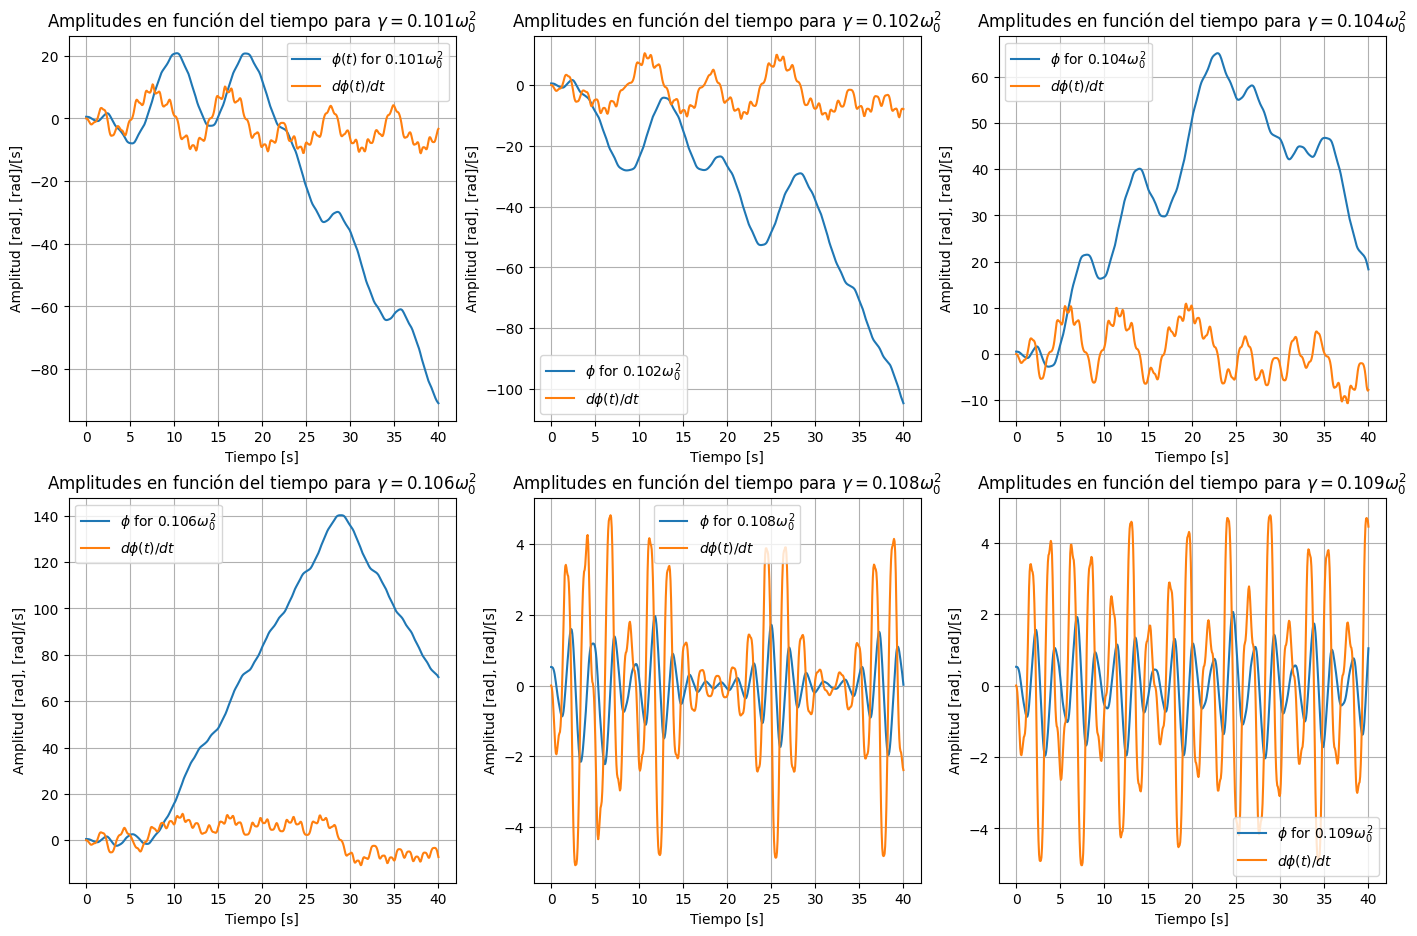

In [ ]:
#@title **Amplitudes en función del tiempo para $\gamma = 0.101\omega_0^2, 0.102\omega_0^2,0.104\omega_0^2,0.106\omega_0^2,0.108\omega_0^2,0.109\omega_0^2$**

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
yo = [np.pi/6,0]
t = np.linspace(0,40,600)

def pend0d(y,t):
  theta,v = y
  dydt = [v,-9.8*w2(t,0.101*9.8)*np.sin(theta)]
  return dydt

def pend1d(y,t):
  theta,v = y
  dydt = [v,-9.8*w2(t,0.102*9.8)*np.sin(theta)]
  return dydt

def pend2d(y,t):
  theta,v = y
  dydt = [v,-9.8*w2(t,0.104*9.8)*np.sin(theta)]
  return dydt

def pend3d(y,t):
  theta,v = y
  dydt = [v,-9.8*w2(t,0.106*9.8)*np.sin(theta)]
  return dydt

def pend4d(y,t):
  theta,v = y
  dydt = [v,-9.8*w2(t,0.108*9.8)*np.sin(theta)]
  return dydt

def pend5d(y,t):
  theta,v = y
  dydt = [v,-9.8*w2(t,0.110*9.8)*np.sin(theta)]
  return dydt

sol0d = odeint(pend0d,yo,t)
sol0d = np.transpose(sol0d)
sol1d = odeint(pend1d,yo,t)
sol1d = np.transpose(sol1d)
sol2d = odeint(pend2d,yo,t)
sol2d = np.transpose(sol2d)
sol3d = odeint(pend3d,yo,t)
sol3d = np.transpose(sol3d)
sol4d = odeint(pend4d,yo,t)
sol4d = np.transpose(sol4d)
sol5d = odeint(pend5d,yo,t)
sol5d = np.transpose(sol5d)

fig,ax = plt.subplots(2,3,figsize=(17,11))


ax[0][0].plot(t,sol0d[0],"-",label="$\phi(t)$ for $0.101\omega_0^2$")
ax[0][0].plot(t,sol0d[1],"-",label= "$d{\phi}(t)/dt$")
ax[0][1].plot(t,sol1d[0],"-",label="$\phi$ for $0.102\omega_0^2$")
ax[0][1].plot(t,sol1d[1],"-",label= "$d{\phi}(t)/dt$")
ax[0][2].plot(t,sol2d[0],"-",label="$\phi$ for $0.104\omega_0^2$")
ax[0][2].plot(t,sol2d[1],"-",label= "$d{\phi}(t)/dt$")
ax[1][0].plot(t,sol3d[0],"-",label="$\phi$ for $0.106\omega_0^2$")
ax[1][0].plot(t,sol3d[1],"-",label= "$d{\phi}(t)/dt$")
ax[1][1].plot(t,sol4d[0],"-",label="$\phi$ for $0.108\omega_0^2$")
ax[1][1].plot(t,sol4d[1],"-",label= "$d{\phi}(t)/dt$")
ax[1][2].plot(t,sol5d[0],"-",label="$\phi$ for $0.109\omega_0^2$")
ax[1][2].plot(t,sol5d[1],"-",label= "$d{\phi}(t)/dt$")




for i in range(2):
  for j in range(3):
    ax[i][j].grid()
    ax[i][j].legend()
    ax[i][j].set_xlabel("Tiempo [s]")
    ax[i][j].set_ylabel("Amplitud [rad], [rad]/[s]")

ax[0][0].set_title("Amplitudes en función del tiempo para $\gamma = 0.101\omega_0^2$")
ax[0][1].set_title("Amplitudes en función del tiempo para $\gamma = 0.102\omega_0^2$")
ax[0][2].set_title("Amplitudes en función del tiempo para $\gamma = 0.104\omega_0^2$")
ax[1][0].set_title("Amplitudes en función del tiempo para $\gamma = 0.106\omega_0^2$")
ax[1][1].set_title("Amplitudes en función del tiempo para $\gamma = 0.108\omega_0^2$")
ax[1][2].set_title("Amplitudes en función del tiempo para $\gamma = 0.109\omega_0^2$")
print('')

Al parecer, cuando $\large \gamma = 0.1\omega_0^2+\epsilon $ con $\large 0<\epsilon<0.06$ se tiene resonancia paramétrica.

Veamos el movimiento del sistema cuando la frecuencia con que varían los parámetros es $0.1\omega_0 ^2$

In [ ]:
#@title **Resonancia paramétrica (sistema no inercial)**
import matplotlib.animation as animation
import math
def animal(l,t,theta):
  """"""
  #-------------------------------------------------------------------------------------------------------------------------------------
  try: #Intente
    #-------------------------------------------------------
    fig = plt.figure(figsize=(6,6)) #Creamos la figura
    ax = fig.gca() #Llamamos los ejes
    x = np.sin(theta)
    y = -np.cos(theta)
    ax.set_title("Péndulo en una nave con $\gamma = 3\omega_0^2$")
    #---------------------------------------------------------------------------------------------
    def actualizar(i): #Definimos la función de update
      #En cada iteración...
      ax.clear() #Limpia la figura
      #Llama dos vectores.
      #El primero va desde 0 hasta x[i]
      #El segundo va desde 0 hasta y[i]
      #Los "suma" y así tenemos el vector que va desde 0 hasta la posición del péndulo
      ax.plot([0,x[i]],[0,y[i]],"-o",markersize=20)
      ax.set_xlim(-1.25*l, 1.25*l) #Los límites en los ejes están calibrados para l=1, así cuando l=0.1, el límite decrece
      ax.set_ylim(-1.25*l, 1.25*l) #Los límites en y están invertidos

      ax.annotate(" x = %.3f m \n y = %.4f m"%(x[i],y[i]), xy=(x[i],y[i]), xytext=[x[i]+l*0.05, y[i]]) #Con esto anotamos los valores de x,y
      ax.annotate("theta = %.3f grados"%(theta[i]*180/math.pi), xy=(x[i],y[i]), xytext=[l*0.1, 0])#Aquí anotamos el valor del ángulo en sexagesimal
      ax.annotate("%.3f segundos"%(t[i]), xy=(x[i],y[i]), xytext=[l*-0.6, l*-0.1]) #Aquí anotamos el paso del tiempo

      ax.grid() #Creamos un grid
    #---------------------------------------------------------------------------------------------

    #Como son 40 segundos --> 40000 ms.
    #Como son 600 frames --> 40000 ms/600 ms/frames
    ani = animation.FuncAnimation(fig,actualizar,range(len(x)),repeat = True, interval = 40000/600)
    #cerramos la figura
    plt.close(fig)
    #------------------------------------------
    return ani #retornamos la animación
  #----------------------------------------------------------------------------------------------------------------------------------------------------------
  except Exception as error: #Si sucede un error
    print(error) #Imprima el error

noinercial = animal(1,t,sol0c[0])
from IPython.display import HTML
HTML(noinercial.to_html5_video())

In [ ]:
#@title **Desplazamiento del sistema no inercial respecto al inercial**
#Para hacer que el sistema sea inercial, debemos hacer que el sistema anterior se mueva con la velocidad de la nave
#Podemos calcular la velocidad de la nave integrando la función de aceleración

from scipy.integrate import quad
from scipy.special import erf
t =  np.linspace(0,20,300)
def w2a(t, f=0.1*9.8):
    return signal.sawtooth(2*np.pi*f*t,width=.5)+1

T = np.linspace(0,40,600)
def v(T):
  jnu,error = quad(w2a,0,T)
  return jnu
#Calculemos la velocidad en cada tiempo muestreado
vy=[]
for i in T:
  vy.append(v(i))

#La animación dura 40 segundos y tiene 600 frames
dt = 40/600

#Calculemos el desplazamiento por frame
yx = []
h = 0
for i in range(len(vy)):
  h += 9.8*vy[i]*dt
  yx.append(h)

print('')

<ipython-input-15-7d404b77eca1>:13: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  jnu,error = quad(w2a,0,T)


Nota: El codigo anterior fué un intento fallido, no afecta los demás anteriores.

In [ ]:
#@title **Resonancia paramétrica (sistema inercial)**
T = np.linspace(0,40,600)
def animala(l,t,theta):
  """ """
  #-------------------------------------------------------------------------------------------------------------------------------------
  try: #Intente
    #-------------------------------------------------------
    fig = plt.figure(figsize=(6,6)) #Creamos la figura
    ax = fig.gca() #Llamamos los ejes
    x = np.sin(theta)
    y = -np.cos(theta)
    #---------------------------------------------------------------------------------------------
    def actualizar(i): #Definimos la función de update
      #En cada iteración...
      ax.clear() #Limpia la figura
      #Llama dos vectores.
      #El primero va desde 0 hasta x[i]
      #El segundo va desde 0 hasta y[i]
      #Los "suma" y así tenemos el vector que va desde 0 hasta la posición del péndulo
      #Le sumamos el desplazamiento en y
      ax.plot([0,x[i]],[0+yx[i],y[i]+yx[i]],"-o",markersize=20)
      ax.arrow(0, yx[i], 0,0.5*w2a(t[i]), head_width=0.1, head_length=0.1,color='black')

      ax.set_xlim(-1.25*l, 1.25*l) #Los límites en los ejes están calibrados para l=1, así cuando l=0.1, el límite decrece
      ax.set_ylim(-1.25*l+yx[i], yx[i]+1.25*l) #Los límites en y están invertidos

      ax.annotate(" x = %.3f m \n y = %.4f m"%(x[i],y[i]), xy=(x[i],y[i]+yx[i]), xytext=[x[i]+l*0.05, yx[i]+y[i]]) #Con esto anotamos los valores de x,y
      ax.annotate("theta = %.3f grados"%(theta[i]*180/math.pi), xy=(x[i],y[i]+yx[i]), xytext=[l*0.1, 0+yx[i]])#Aquí anotamos el valor del ángulo en sexagesimal
      ax.annotate("%.3f segundos"%(t[i]), xy=(x[i],y[i]+yx[i]), xytext=[l*-0.6, yx[i]+l*-0.1]) #Aquí anotamos el paso del tiempo
      ax.annotate("%.3f Aceleración"%(9.8*w2a(t[i])), xy=(x[i],y[i]+yx[i]+0.5), xytext=[l*-0.6, yx[i]+l*-0.1+0.5]) #Aquí anotamos el paso del tiempo

      ax.grid() #Creamos un grid
    #---------------------------------------------------------------------------------------------

    #Como son 20 (10) segundos --> 20000 (10000) ms.
    #Como son 200 frames --> 20000 ms/200 (10000)/(400)frames ---> 100ms/frames
    ani = animation.FuncAnimation(fig,actualizar,range(len(x)),repeat = True, interval = 20000/300)
    #cerramos la figura
    plt.close(fig)
    #------------------------------------------
    return ani #retornamos la animación
  #----------------------------------------------------------------------------------------------------------------------------------------------------------
  except Exception as error: #Si sucede un error
    print(error) #Imprima el error

inerciala = animala(1,T,sol0c[0])
from IPython.display import HTML
HTML(inerciala.to_html5_video())

Output hidden; open in https://colab.research.google.com to view.

## **CONCLUSIONES**

El problema de un péndulo simple montado en un sistema no inercial como lo es una nave acelerando verticalmente hacia arriba puede ser estudiado como un oscilador paramétrico. Cuando la frecuencia del sistema se comporta como una onda cuadrada es muy fácil que el sistema sea resonante. Por el contrario, cuando la frecuencia se comporta como una función diente de sierra, es complicado encontrar las condiciones para que el sistema sea resonante. Se encontró que para el ultimo caso, si la frecuencia con que varían los parámetros es $\large\gamma = 0.1\omega_0^2 + \epsilon$, habrá resonancia cuando $\large 0<\epsilon<0.06$. Donde $\omega_0^2$ es la frecuencia promedio del sistema. Como comentario adicional, es interesante la aparición del fenómeno de las pulsaciones cuando los parámetros se comportaban como la función diente de sierra con frecuencia $\gamma = 0.02\omega_0^2,0.003\omega_0^2, 0.108\omega_0^2$ y  $0.109\omega_0^2$ con una amplitud de $9.8$